# MobilityAPI — Tutorial

This notebook walks through the [OGC API – Moving Features](https://docs.ogc.org/is/22-003r3/22-003r3.html)
endpoints exposed by **MobilityAPI**, using one day of AIS (Automatic
Identification System) data published by the [Danish Maritime Authority](http://aisdata.ais.dk/).

The OGC standard models a moving feature as a `Feature` with a
`temporalGeometry` (e.g. a `MovingPoint`) and optional `temporalProperties`,
grouped into named `Collections`. MobilityAPI exposes these as REST
resources.

<img src="doc/images/ogc-moving-features-class-diagram.png" alt="OGC API – Moving Features class diagram" width="720">

*Class diagram for OGC API – Moving Features – Part 1: Core ([standard document, fig. 1](https://docs.ogc.org/is/22-003r3/22-003r3.html)).*

## Endpoints covered

| Step | Endpoint | Purpose |
|------|----------|---------|
| 0 | `DELETE /collections/{id}` | clean any pre-existing state |
| 1 | `POST   /collections` | create the `ships` collection |
| 2 | `GET    /collections` | list collections |
| 3 | `POST   /collections/{id}/items` | insert vessels as a `FeatureCollection` of `MovingPoint` features |
| 4 | `GET    /collections/{id}/items` | list / paginate vessels |
| 5 | `GET    /collections/{id}/items?bbox=…` | spatial filter on a port envelope |
| 6 | `GET    /collections/{id}/items/{mFeatureId}/tgsequence` | inspect a vessel's temporal-geometry sequence |
| 7 | `GET    /…/tgsequence/{tGeometryId}/velocity` | derived measure on a sequence, with multi-vessel comparison |
| 8 | `GET    /collections/{id}/items?subTrajectory=…&datetime=…` | temporal slice |

## Prerequisites

1. **MobilityAPI server running** on `http://localhost:8080` (`./run.sh`).
2. **AIS dataset prepared** at `data/trajectories_mf1.json` (see README — produced from `aisdk-2024-08-07.zip` by `data/ais_to_json.py`).


## Setup


In [1]:
import os
import json
import requests
import ijson

import matplotlib.pyplot as plt
import pandas as pd
import contextily as cx
from shapely.geometry import LineString, Point, box
import geopandas as gpd

from pymeos import pymeos_initialize, pymeos_finalize

pymeos_initialize()

HOST = "http://localhost:8080"
COLLECTION_ID = "ships"

DATA_PATH = os.path.join(os.getcwd(), "data", "trajectories_mf1.json")
assert os.path.exists(DATA_PATH), (
    f"Expected AIS file at {DATA_PATH}. "
    "Run data/ais_to_json.py first — see README."
)


A small helper that streams features from the AIS JSON file without loading
the full 80 MB document into memory.


In [2]:
def iter_features(path, limit=None):
    with open(path, "rb") as fh:
        for i, obj in enumerate(ijson.items(fh, "item")):
            if limit is not None and i >= limit:
                break
            yield obj


## Step 0 — Reset state

`DELETE /collections/{collectionId}` removes a collection and its items.
This makes the tutorial idempotent — re-running from the top yields the
same result every time.


In [3]:
resp = requests.delete(f"{HOST}/collections/{COLLECTION_ID}")
print(f"DELETE /collections/{COLLECTION_ID} → {resp.status_code}")


DELETE /collections/ships → 404


## Step 1 — Create the `ships` collection

`POST /collections` registers a new moving-feature collection. The body
follows the OGC API – Moving Features schema for a `Collection`:

| Field            | Meaning                              |
|------------------|--------------------------------------|
| `title`          | Stable identifier (also the URL key) |
| `description`    | Human-readable summary               |
| `itemType`       | Always `movingfeature` here          |
| `updateFrequency`| Suggested polling interval (ms)      |

Server-side, MobilityAPI persists these resources across four tables
(`collections`, `moving_features`, `temporal_geometries`,
`temporal_properties`/`temporal_values`):

<img src="doc/images/mobilityapi-backing-schema.png" alt="MobilityAPI backing PostgreSQL schema" width="720">

*The PostgreSQL schema MobilityAPI creates on first POST. `moving_features.bbox` and `moving_features.time` use MobilityDB's `STBOX` / `TSTZSPAN` types; `temporal_geometries.trajectory` is a `tgeompoint`.*


In [4]:
collection = {
    "title": COLLECTION_ID,
    "description": "Ship trajectories from the Danish Maritime Authority (one day of AIS observations).",
    "itemType": "movingfeature",
    "updateFrequency": 1000,
}

resp = requests.post(f"{HOST}/collections", json=collection)
assert resp.status_code in (201, 409), resp.text
print(f"POST /collections → {resp.status_code}")
print(json.dumps(resp.json(), indent=2))


POST /collections → 201
{
  "id": "ships",
  "title": "ships",
  "description": "Ship trajectories from the Danish Maritime Authority (one day of AIS observations).",
  "itemType": "movingfeature",
  "updateFrequency": 1000,
  "extent": null,
  "links": [
    {
      "href": "http://localhost:8080/collections/ships",
      "rel": "self",
      "type": "application/json"
    },
    {
      "href": "http://localhost:8080/collections/ships/items",
      "rel": "items",
      "type": "application/json"
    }
  ]
}


## Step 2 — List collections

`GET /collections` returns metadata for every registered collection,
along with HATEOAS links to the canonical sub-resources.


In [5]:
resp = requests.get(f"{HOST}/collections")
assert resp.status_code == 200
print(f"GET /collections → {resp.status_code}")
print(json.dumps(resp.json(), indent=2))


GET /collections → 200
{
  "collections": [
    {
      "id": "ships",
      "title": "ships",
      "description": "Ship trajectories from the Danish Maritime Authority (one day of AIS observations).",
      "itemType": "movingfeature",
      "updateFrequency": 1000,
      "extent": null,
      "links": [
        {
          "href": "http://localhost:8080/collections/ships",
          "rel": "self",
          "type": "application/json"
        },
        {
          "href": "http://localhost:8080/collections/ships/items",
          "rel": "items",
          "type": "application/json"
        }
      ]
    }
  ],
  "links": [
    {
      "href": "http://localhost:8080/collections",
      "rel": "self",
      "type": "application/json"
    }
  ]
}


## Step 3 — Insert vessels

`POST /collections/{collectionId}/items` accepts either a single `Feature`
or a `FeatureCollection`. Each feature carries:

- `id` — the vessel MMSI in our case
- `properties` — arbitrary metadata
- `crs` / `trs` — coordinate and temporal reference systems
- `temporalGeometry` — a `MovingPoint` with parallel `coordinates` /
  `datetimes` arrays plus an interpolation rule

We stream the AIS JSON file and POST in small batches so the request bodies
stay below the server's payload limit.


In [6]:
BATCH_SIZE = 20

def to_feature(obj):
    return {
        "type": "Feature",
        "id": str(obj["mmsi"]),
        "properties": obj.get("properties") or {},
        "crs": {
            "type": "name",
            "properties": {"name": "urn:ogc:def:crs:EPSG::25832"},
        },
        "trs": {
            "type": "Link",
            "properties": {
                "type": "ogcdef",
                "href": "http://www.opengis.net/def/uom/ISO-8601/0/Gregorian",
            },
        },
        "temporalGeometry": json.loads(obj["trajectory"]) if isinstance(obj["trajectory"], str) else obj["trajectory"],
    }


def post_batch(batch):
    payload = {"type": "FeatureCollection", "features": [to_feature(o) for o in batch]}
    r = requests.post(
        f"{HOST}/collections/{COLLECTION_ID}/items",
        json=payload,
        headers={"Content-Type": "application/json"},
    )
    return r.status_code, len(batch)


created = 0
batch = []
for obj in iter_features(DATA_PATH):
    batch.append(obj)
    if len(batch) >= BATCH_SIZE:
        status, n = post_batch(batch)
        if status in (201, 409):
            created += n
        batch = []
if batch:
    status, n = post_batch(batch)
    if status in (201, 409):
        created += n

print(f"Inserted {created} vessels into collection '{COLLECTION_ID}'.")


Inserted 143 vessels into collection 'ships'.


## Step 4 — List vessels

`GET /collections/{collectionId}/items` returns the `FeatureCollection`
of vessels. The `limit` query parameter caps the page size.


In [7]:
LIMIT = 50
resp = requests.get(
    f"{HOST}/collections/{COLLECTION_ID}/items",
    params={"limit": LIMIT},
)
assert resp.status_code == 200
features = resp.json().get("features", [])
print(f"GET /collections/{COLLECTION_ID}/items?limit={LIMIT} → {len(features)} features")


GET /collections/ships/items?limit=50 → 50 features


Render every returned trajectory on a map.

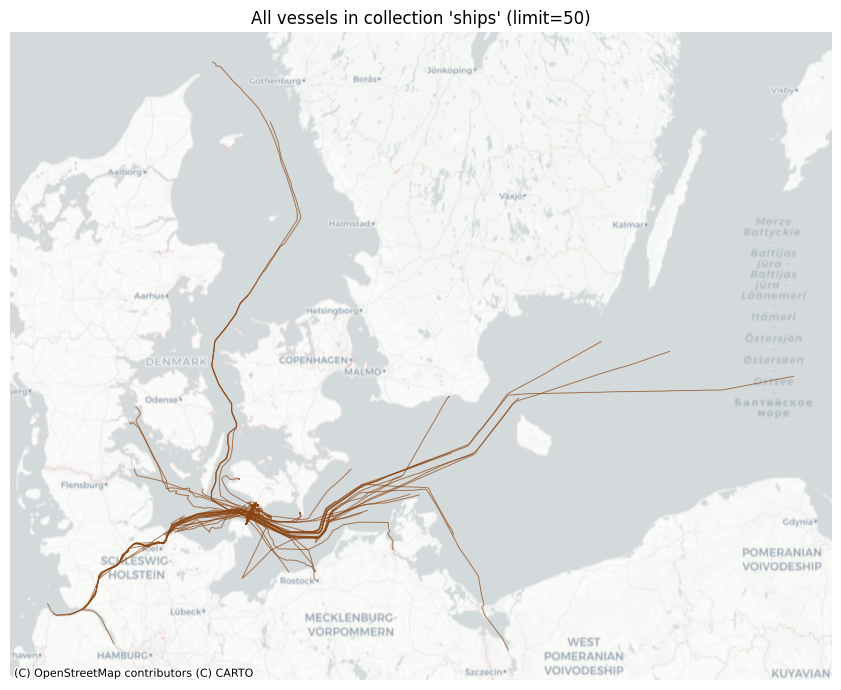

In [8]:
def features_to_gdf(features, source_crs="EPSG:25832"):
    """Build a WGS84 GeoDataFrame from MobilityAPI feature responses.

    Handles two response shapes the server emits:
    - `geometry`: a list of static GeoJSON geometries (e.g. LineString) — bbox / subTrajectory paths
    - `temporalGeometry`: a list of MovingPoint objects with parallel `coordinates` / `datetimes`
    """
    geoms, ids = [], []
    for feat in features:
        coords = []
        for g in feat.get("geometry") or []:
            coords.extend(g.get("coordinates", []))
        if not coords:
            for tg in feat.get("temporalGeometry") or []:
                coords.extend(tg.get("coordinates", []))
        if not coords:
            continue
        geoms.append(LineString(coords) if len(coords) > 1 else Point(coords[0]))
        ids.append(feat.get("id"))
    if not geoms:
        return gpd.GeoDataFrame({"id": []}, geometry=[], crs=source_crs).to_crs(4326)
    return gpd.GeoDataFrame({"id": ids}, geometry=geoms, crs=source_crs).to_crs(4326)


gdf_all = features_to_gdf(features)

fig, ax = plt.subplots(figsize=(9, 7))
gdf_all.plot(ax=ax, color="saddlebrown", linewidth=0.7, alpha=0.7)
ax.set_axis_off()
ax.set_title(f"All vessels in collection '{COLLECTION_ID}' (limit={LIMIT})")
cx.add_basemap(ax, crs=gdf_all.crs, source=cx.providers.CartoDB.Positron)
plt.tight_layout()
plt.show()


## Step 5 — Spatial filter (`bbox`)

`GET /collections/{collectionId}/items?bbox=minx,miny,maxx,maxy` keeps
only the vessels whose trajectory intersects the supplied envelope. The
coordinates are in the collection's storage CRS — EPSG:25832 for this
dataset.

We pick a tight envelope around **Rødby harbour** (south-east Denmark).


In [9]:
PORT_BBOX = "651135,6058230,651422,6058548"  # Rødby harbour (EPSG:25832, metres)

resp = requests.get(
    f"{HOST}/collections/{COLLECTION_ID}/items",
    params={"bbox": PORT_BBOX, "limit": 97},
)
assert resp.status_code == 200
features_bbox = resp.json().get("features", [])
print(f"GET /collections/{COLLECTION_ID}/items?bbox=… → {len(features_bbox)} features")


GET /collections/ships/items?bbox=… → 97 features


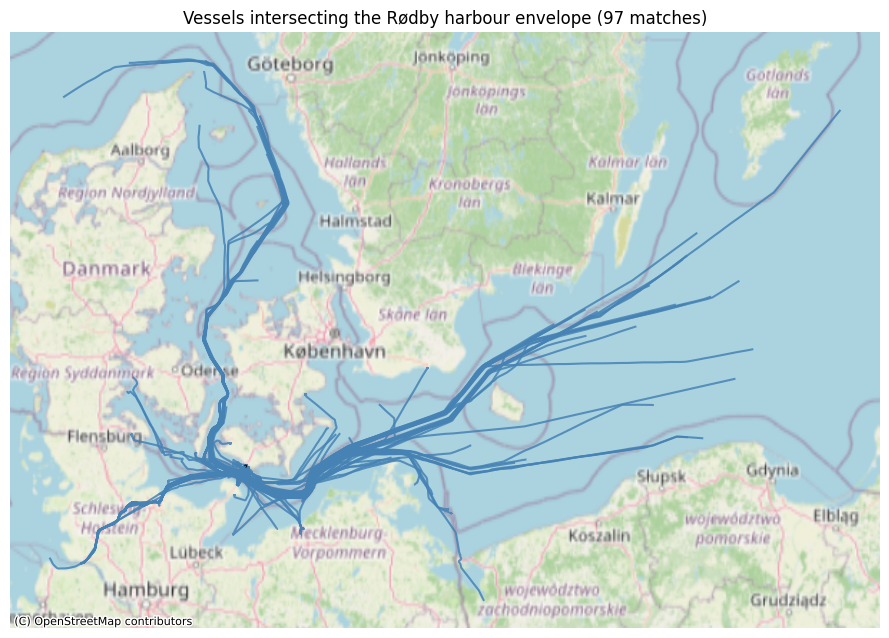

In [10]:
gdf_bbox = features_to_gdf(features_bbox)

minx, miny, maxx, maxy = map(float, PORT_BBOX.split(","))
gdf_env = gpd.GeoDataFrame(
    {"name": ["Rødby harbour envelope"]},
    geometry=[box(minx, miny, maxx, maxy)],
    crs="EPSG:25832",
).to_crs(4326)

fig, ax = plt.subplots(figsize=(9, 7))
if not gdf_bbox.empty:
    gdf_bbox.plot(ax=ax, color="steelblue", linewidth=1.5, alpha=0.85)
gdf_env.boundary.plot(ax=ax, color="black", linewidth=2)
ax.set_axis_off()
ax.set_title(f"Vessels intersecting the Rødby harbour envelope ({len(gdf_bbox)} matches)")
cx.add_basemap(ax, crs=gdf_env.crs, source=cx.providers.OpenStreetMap.Mapnik)
plt.tight_layout()
plt.show()


## Step 6 — Inspect a vessel's temporal-geometry sequence

`GET /collections/{collectionId}/items/{mFeatureId}/tgsequence` returns
the `TemporalGeometrySequence` for one vessel. Each element of the
sequence has an `id` we use in the next step to ask the server for
derived measures.


In [11]:
ship_ids = [f["id"] for f in features_bbox] if features_bbox else [features[0]["id"]]
ship_id = ship_ids[0]

resp = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items/{ship_id}/tgsequence")
assert resp.status_code == 200
sequence = resp.json()
print(f"GET /…/items/{ship_id}/tgsequence → "
      f"{len(sequence.get('geometrySequence', []))} segment(s)")
geom_id = sequence["geometrySequence"][0]["id"]
print(f"\nFirst segment id: {geom_id}")


GET /…/items/209168000/tgsequence → 1 segment(s)

First segment id: 435


## Step 7 — Derived measure: velocity (multi-vessel comparison)

`GET /collections/{collectionId}/items/{mFeatureId}/tgsequence/{tGeometryId}/velocity`
returns a `TReal` — a temporal-real value sampled at each timestamp the
trajectory passes through. Other supported `queryType` values include
`distance` and `acceleration`.

Below we fetch the velocity profile for the first few vessels in the
bbox-port query and plot them on a shared time axis with a **10-knot
speed-limit reference** (5.14 m/s) so over-limit segments stand out.


In [12]:
def fetch_velocity(ship_id):
    r = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items/{ship_id}/tgsequence")
    if r.status_code != 200:
        return None
    seq = r.json().get("geometrySequence", [])
    if not seq:
        return None
    gid = seq[0]["id"]
    r = requests.get(
        f"{HOST}/collections/{COLLECTION_ID}/items/{ship_id}/tgsequence/{gid}/velocity"
    )
    if r.status_code != 200:
        return None
    return r.json()


PROFILES = []
for sid in ship_ids[:4]:
    v = fetch_velocity(sid)
    if v and v.get("values"):
        PROFILES.append((sid, v))

print(f"Fetched velocity profiles for {len(PROFILES)} vessel(s):")
for sid, v in PROFILES:
    print(f"  vessel {sid}: {len(v['values'])} samples, unit={v['unit']}")


Fetched velocity profiles for 4 vessel(s):
  vessel 209168000: 3805 samples, unit=m/s
  vessel 209184000: 9262 samples, unit=m/s
  vessel 209530000: 6150 samples, unit=m/s
  vessel 209892000: 3153 samples, unit=m/s


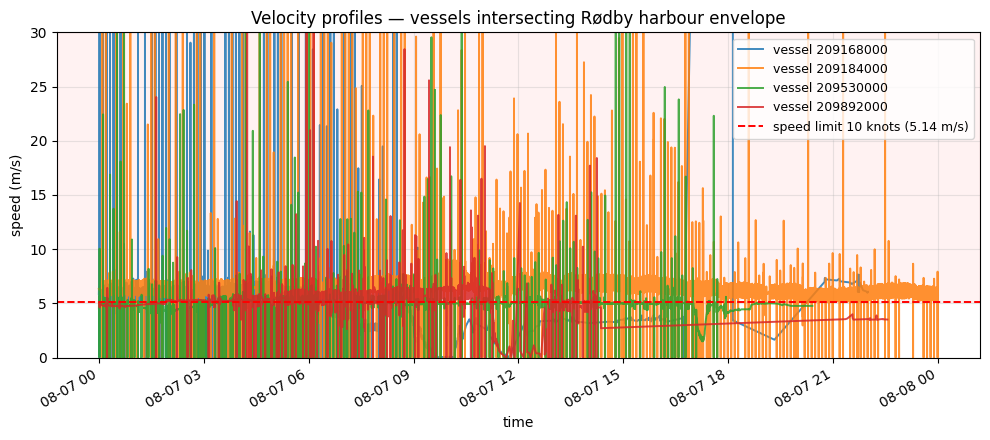

In [13]:
SPEED_LIMIT_KNOTS = 10
SPEED_LIMIT_MS = SPEED_LIMIT_KNOTS * 0.5144  # 1 knot ≈ 0.5144 m/s
Y_CAP_MS = 30  # cap the y-axis: AIS positional jitter occasionally produces unrealistic velocity spikes

fig, ax = plt.subplots(figsize=(10, 4.5))
for sid, vel in PROFILES:
    df = pd.DataFrame(vel["values"])
    df["time"] = pd.to_datetime(df["time"])
    ax.plot(df["time"], df["value"], linewidth=1.4, alpha=0.85, label=f"vessel {sid}")

ax.axhline(SPEED_LIMIT_MS, color="red", linestyle="--", linewidth=1.4,
           label=f"speed limit {SPEED_LIMIT_KNOTS} knots ({SPEED_LIMIT_MS:.2f} m/s)")
ax.axhspan(SPEED_LIMIT_MS, Y_CAP_MS, color="red", alpha=0.05)
ax.set_ylim(0, Y_CAP_MS)
ax.set_title("Velocity profiles — vessels intersecting Rødby harbour envelope")
ax.set_ylabel(f"speed ({PROFILES[0][1]['unit']})")
ax.set_xlabel("time")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


Some vessels accelerate and brake (typical port arrival/departure), others
stay at zero (anchored). Compared against the dashed red speed-limit line,
any sample sitting above the dashed line is a violation in that interval.
The same `queryType=distance` / `acceleration` calls work in place of
`velocity` for the other two derived measures.


## Step 8 — Temporal slice (`subTrajectory`)

`GET /collections/{collectionId}/items?subTrajectory=true&datetime=<start>/<end>`
returns each vessel restricted to the requested time interval. The
`datetime` parameter follows the [RFC 3339 interval syntax](https://www.rfc-editor.org/rfc/rfc3339).


In [14]:
TIME_INTERVAL = "2024-08-07T10:30:00+00/2024-08-07T11:30:00+00"

resp = requests.get(
    f"{HOST}/collections/{COLLECTION_ID}/items",
    params={"subTrajectory": "true", "datetime": TIME_INTERVAL, "limit": 137},
)
assert resp.status_code == 200
features_sub = resp.json().get("features", [])
print(f"GET /…/items?subTrajectory=true&datetime={TIME_INTERVAL} → "
      f"{len(features_sub)} features")


GET /…/items?subTrajectory=true&datetime=2024-08-07T10:30:00+00/2024-08-07T11:30:00+00 → 137 features


Summarise the vessels that have at least one sample inside the requested
window:


In [15]:
sub_rows = []
for feat in features_sub[:10]:
    times = []
    for tg in feat.get("temporalGeometry") or []:
        times.extend(tg.get("datetimes", []))
    sub_rows.append({
        "id": feat.get("id"),
        "name": (feat.get("properties") or {}).get("Name") or "—",
        "ship_type": (feat.get("properties") or {}).get("ShipType") or "—",
        "first": times[0] if times else None,
        "last": times[-1] if times else None,
        "n_samples": len(times),
    })

pd.DataFrame(sub_rows)


,id,name,ship_type,first,last,n_samples
0,205106000,MARCUS,Cargo,2024-08-07T11:04:09+00,2024-08-07T11:30:00+00,2
1,205196000,NP 460,Other,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,30
2,205210000,WISMAR,Other,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,357
3,205214000,MAYA,Other,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,353
4,205362800,RUPEL,Sailing,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,55
5,209168000,AGATH,Tanker,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,17
6,209184000,IMAVERE,Cargo,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,440
7,209332000,RIX PACIFIC,Cargo,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,2
8,209530000,AMISIA,Cargo,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,357
9,209543000,THETIS D,Cargo,2024-08-07T10:30:00+00,2024-08-07T11:30:00+00,35


Overlay the temporal slice (green) on the full set of trajectories (brown)
to see how vessels were moving during the requested window.


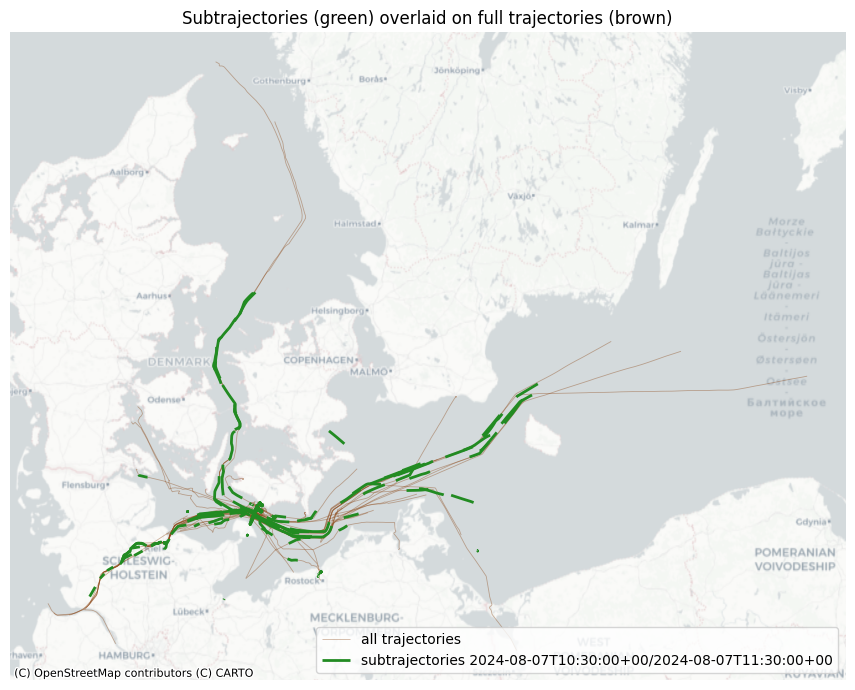

In [16]:
gdf_sub = features_to_gdf(features_sub)

fig, ax = plt.subplots(figsize=(9, 7))
gdf_all.plot(ax=ax, color="saddlebrown", linewidth=0.6, alpha=0.4, label="all trajectories")
if not gdf_sub.empty:
    gdf_sub.plot(ax=ax, color="forestgreen", linewidth=2.0, alpha=1.0,
                 label=f"subtrajectories {TIME_INTERVAL}")
ax.set_axis_off()
ax.set_title("Subtrajectories (green) overlaid on full trajectories (brown)")
ax.legend(loc="lower right", frameon=True)
cx.add_basemap(ax, crs=gdf_all.crs, source=cx.providers.CartoDB.Positron)
plt.tight_layout()
plt.show()


## Where next

- **OGC standard**: [OGC API – Moving Features – Part 1: Core](https://docs.ogc.org/is/22-003r3/22-003r3.html)
- **MobilityAPI source**: [`MobilityDB/MobilityAPI`](https://github.com/MobilityDB/MobilityAPI)
- **Underlying types**: [PyMEOS](https://github.com/MobilityDB/PyMEOS) for in-process MEOS access; [MobilityDB](https://github.com/MobilityDB/MobilityDB) for the SQL layer
- **Other endpoints not covered here**: `PUT /collections/{id}`,
  `…/tproperties` for temporal-property streams, and the `distance` /
  `acceleration` query types alongside `velocity`.


In [17]:
pymeos_finalize()
